In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


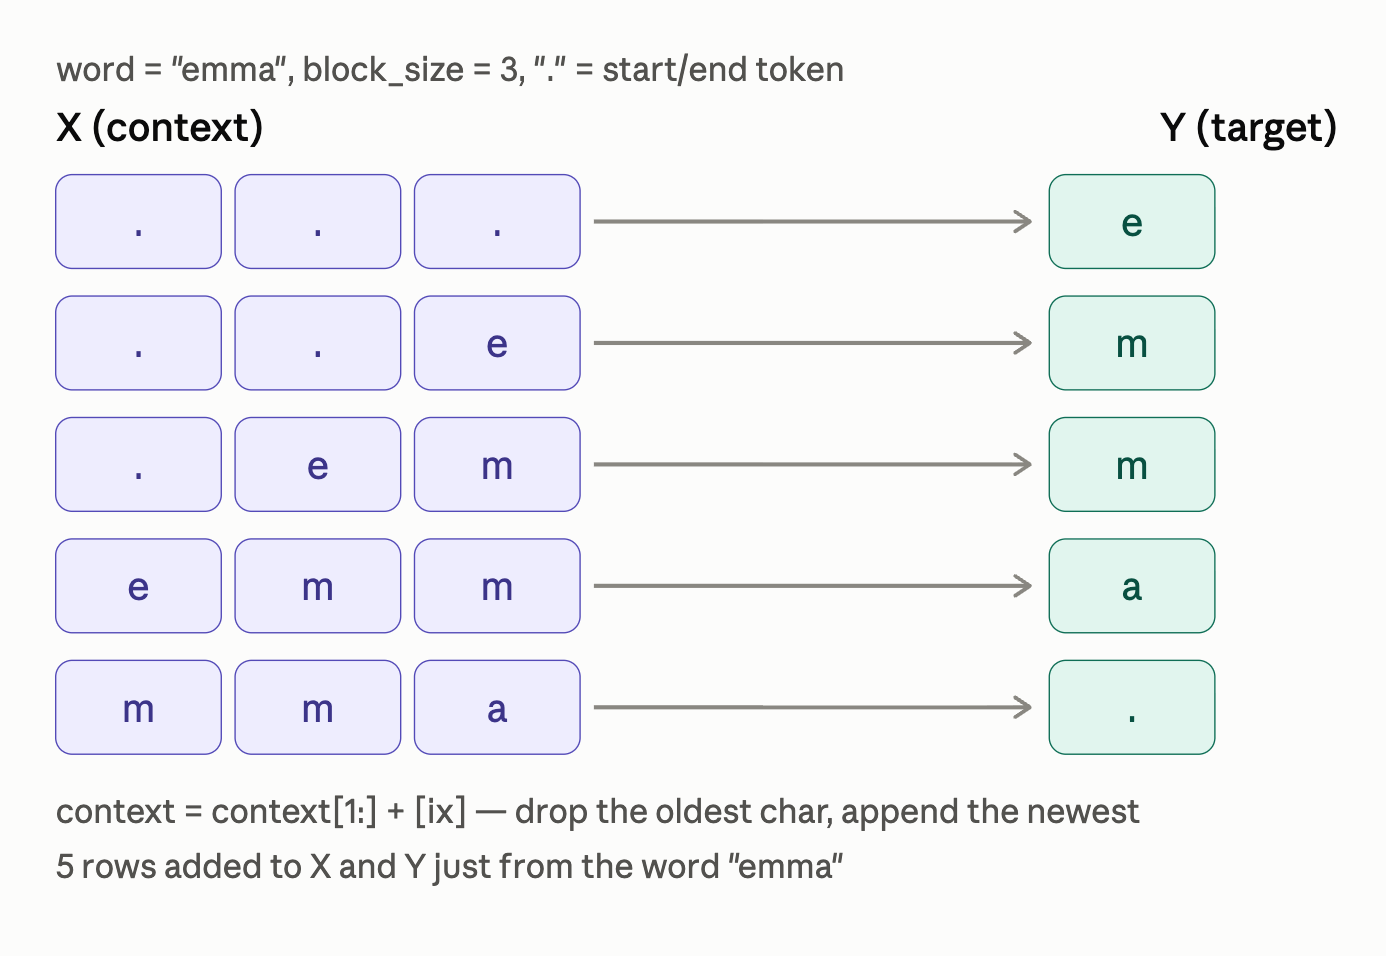

This is the dataset-building step for the MLP version of the character model — a major upgrade over the bigram approach, since instead of looking at just 1 previous character, it now looks at block_size previous characters as context.

Line by line

block_size = 3 — how many previous characters the model gets to see before predicting the next one. Where the bigram model only ever knew "the last 1 character," this model gets 3 characters of history — much richer context.

context = [0] * block_size — every word starts with a context of [0, 0, 0] — three copies of the padding token's index (., index 0), since there's no real history yet at the start of a word. This is the same start-token idea from your bigram diagrams, just repeated block_size times instead of once.

for ch in w + '.': — walks through every character of the word, plus one final . appended, so the model also learns when a word ends, same reasoning as before.

X.append(context) — records the current 3-character context as one training input.
Y.append(ix) — records the character that actually comes next, as the target for that context.

context = context[1:] + [ix] — this is the sliding window mechanism, and the key new mechanic here. context[1:] drops the oldest character (the first element), and + [ix] appends the character that was just predicted onto the end. This shifts the 3-character window forward by exactly one position each iteration — "crop and append," as the comment says.

Why this matters

With the bigram model, N[ix1, ix2] could only ever learn "given this 1 character, what comes next" — extremely limited context. This sliding window setup produces training examples where X has shape (num_examples, 3) — every row is 3 character indices — and Y has shape (num_examples,) — the single correct next character for each. This is exactly the input shape an MLP needs: a fixed-size numeric vector in, one prediction out. Feeding in 3 characters of context (rather than 1) lets the network learn much richer patterns, like "after 'th', an 'e' is very likely" — something a bigram model structurally cannot represent, since it never sees more than one character back.

build_dataset(words): same sliding-window logic, now packaged as a function

This is identical to the X/Y construction you looked at earlier (the emma sliding-context diagram) — it's just wrapped in a reusable function now, since you need to build this dataset structure three separate times, once for each data split. Same mechanics as before: pad with [0]*block_size, walk each character plus the end token ., record the current context into X and the next character into Y, then slide the window forward by dropping the oldest character and appending the new one. print(X.shape, Y.shape) just gives you a quick sanity check of how many training rows each split produced.

Why split the data into three groups at all

This is a standard machine learning practice, and it directly addresses something your earlier exercises didn't need to worry about: how do you know if your model has actually learned general patterns, versus just memorized the specific names it was trained on?

Xtr/Ytr (80%) — training set. This is the only data the model's weights are ever updated on — every loss.backward() and parameter update in your training loop uses only this data.
Xdev/Ydev (10%) — dev/validation set. The model never trains on this data directly, but you do use it repeatedly — to check the loss on names it hasn't memorized, and to decide things like hyperparameters (embedding size, hidden layer size, learning rate) by comparing how different choices perform here.
Xte/Yte (10%) — test set. Held back and checked only once, at the very end, after all tuning decisions are already locked in. This gives you an honest, unbiased final estimate of how well the model generalizes to genuinely unseen names — since if you kept tweaking things based on test set performance, you'd effectively be "training" on it indirectly, defeating its purpose as a truly held-out check.
Why shuffle before splitting

names.txt is stored in whatever order Karpathy's original file happened to list names — potentially not random (e.g., alphabetical, or by some other grouping). If you split words[:n1], words[n1:n2], words[n2:] without shuffling first, you'd risk each split containing systematically different kinds of names (e.g., all training names starting with early letters, all test names starting with late letters) — a biased split that could make your dev/test evaluation misleading.

random.shuffle(words) randomizes the order first, so each split ends up as a representative, random sample of the full dataset — not skewed by whatever incidental ordering existed in the original file.

Why random.seed(42) specifically

Same reproducibility concept as the torch.Generator().manual_seed(...) calls from earlier — without a fixed seed, random.shuffle would produce a different random order every time you ran the notebook, meaning your train/dev/test splits would differ from run to run. That would make it impossible to fairly compare two different training attempts (different hyperparameters, different architectures) — you wouldn't know if a change in dev loss came from your actual model change, or just from happening to get an easier/harder random split this time. Fixing the seed means every re-run produces the exact same 80/10/10 split, keeping comparisons fair and results reproducible.

In [7]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [8]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [9]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

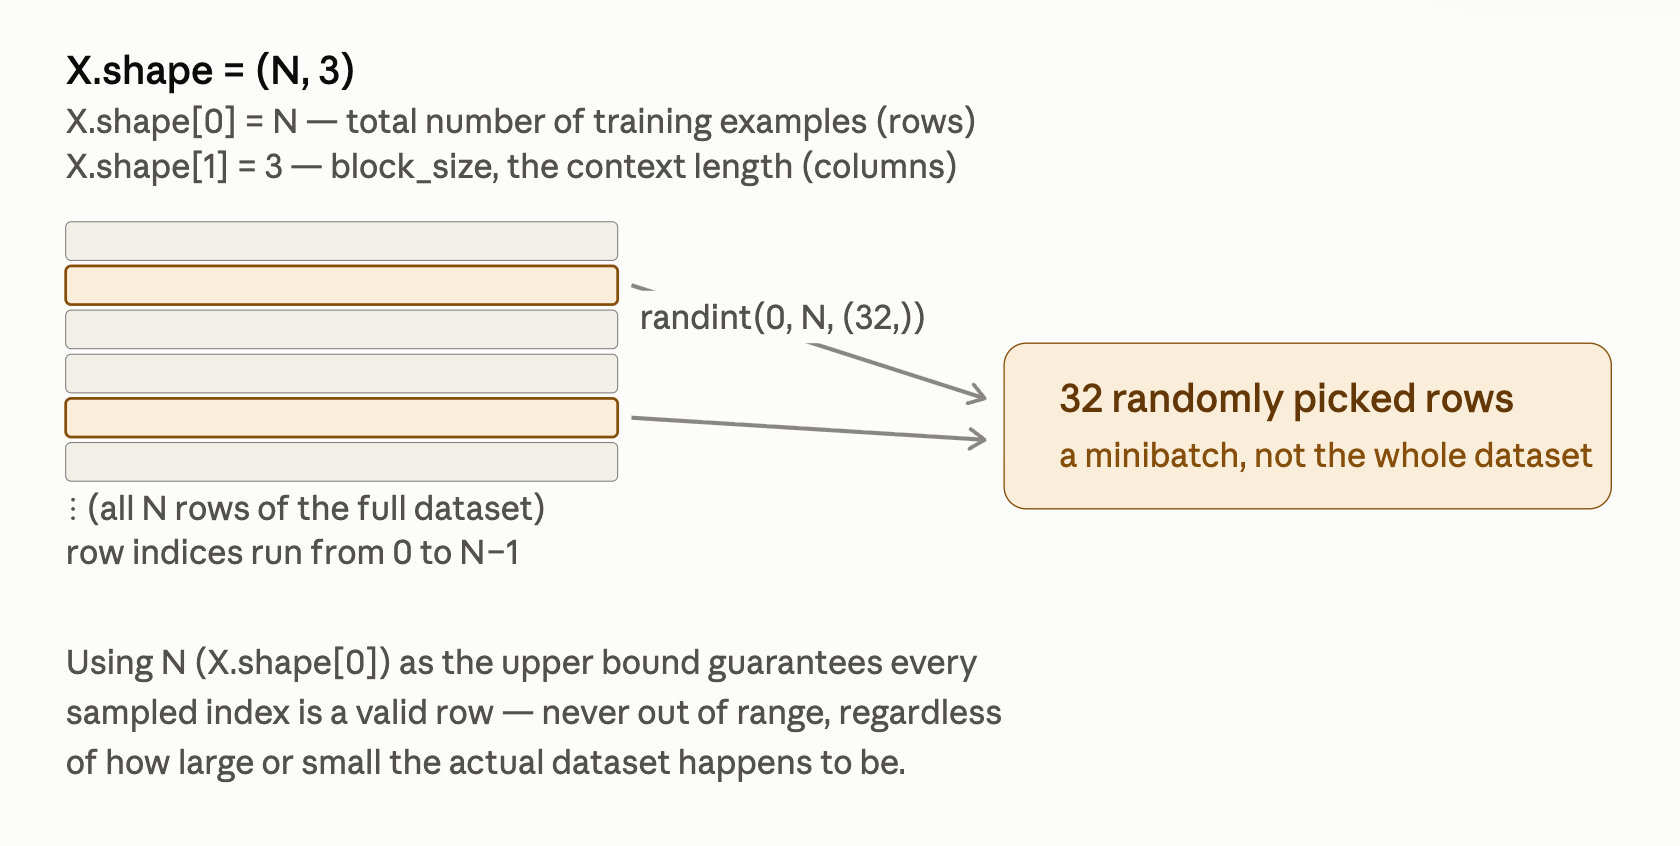

What X.shape[0] actually is

Recall X has shape (N, 3) — N rows (one per training example) and 3 columns (the context characters, from block_size=3). X.shape[0] pulls out the first dimension's size, which is N — the total number of training examples in your entire dataset (potentially tens of thousands, since it's built from every character transition across all 32,033 names).

Why it's needed as the upper bound in torch.randint
python
torch.randint(0, X.shape[0], (32,))

torch.randint(low, high, size) generates random integers in the range [low, high). Here, that means: generate 32 random integers, each somewhere between 0 and N-1. Each of these random integers is meant to be used as a row index into X and Y — i.e., "pick this specific training example."

The reason X.shape[0] specifically (not some fixed number like 1000) is critical: it guarantees every randomly generated index is a valid row in your actual dataset, no matter how large N actually is. If you hardcoded some arbitrary number as the upper bound instead, you'd risk either:

Too high → generating an index that's out of bounds, causing an IndexError when you try X[idx]
Too low → never sampling from large portions of your dataset at all, biasing training toward only the first chunk of examples
Why sample a minibatch at all, instead of using the whole dataset every step

This is the broader concept this line supports: instead of computing the loss and gradient over your entire dataset on every single training iteration (which is what your first working loop did, and is called full-batch gradient descent), this samples just 32 random rows each time — a minibatch. This makes each training step much faster (only 32 examples' worth of forward/backward computation, not tens of thousands), at the cost of each individual step being a noisier, less precise estimate of the true gradient. In practice, this trade-off is almost always worth it — you can take many more, faster steps in the same amount of time, which typically trains faster overall than fewer, slower, more "precise" full-batch steps.